## **LAB Deep Learning Session 1**

kuis per 6 40%

quiz pert 12 60%

dataset gausah dikumpul

pake vs code .ipynb

1. perceptron = salah satu unit ntron (sigma sum)
tugasnya menerima input, dia gabungan
input * weights = lalu ** bias, agar dia 0.05 (kecil)

dikasih bias biar dia ga pakem

2. weights and bias
3. layers
input layer - hidden layer (tempat activition layer bekerja) - output layer (activiton + loss function)

4. activation function = untuk menentukan bentuk outputnya, mau binary kah atau dll nya

kegunaan activition function berbeda, contoh:
1. identity/linear activation function (default), kalo buat dl -> outputnya (- infinite, +infinite)
2. Leaky ReLU -> bisa 0 koma 0,
3. SoftMax

kepake buat sesi ini sigmoid, linear, dan ReLU

activation function ada pasangannya

SLP & MLP
SLP = input layer + output layer (activition func hanya di output) MIN 3 hidden layer
MLP = ada di hidden layer dan output layer activition functionnya

MLP SHALLOW / DEEP

model ada hasilnya = overfitt, underfitt, balance

MLP Biasanya pasti overfitt, nnti ada solvenya biar dia ga overfitt

CARA SOLVE OVERFIT
- Dropout = dia matiin 1 neuron secara acak, agar informasi tersebar merata

Loss Function (binary cost-entropy BCE)
berguna untuk mengukur seberapa meleset tebakan model, lalu dijadikan satu angka yang diperjecuk terus menerus selama training.

pake backprop sampe dia menemukan learning rate yang sesuai.
kan kalo ml kita tentuin sendiri learning ratenya berapa, kalo di dl ga perlu

thats why harus cari pasangannya dengan benar
kalo pake sigmoid = BEC
Linear = CCE

ONE HOT ENCODING
untuk ubah dari text -> angka.





dataset telephone, prediksi yang bakal ninggalin service kita

In [18]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Membaca dataset sesuai nama file
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Menampilkan 5 baris pertama
df.head()

Saving requirements.txt.txt to requirements.txt (1).txt
Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
df = pd.read_csv('./WA_Fn-UseC_-Telco-Customer-Churn.csv')
print ("Shape:", df.shape)
df.head()
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [22]:
# ubah data anomaly ke bentuk yang optimal (Total Charge harusnya uang tapi string(object) -> int)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # coerce ubah error jadi NAN

print("Missing:", df['TotalCharges'].isna().sum())

# df.dropna()
# df.info()
df.dropna(inplace=True)

print("Missing:", df['TotalCharges'].isna().sum())

df.info()

Missing: 11
Missing: 0
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 n

In [23]:
# hapus cust ID dan One Hot Encoding
df=df.drop(columns='customerID')

# drop id karena nilainya unique dan model gabisa nemuin pola dari valu unique
y=df['Churn'].map({'Yes':1, 'No':0}) # Y ada kunci jawaban
x=df.drop(columns=['Churn']) # X ga punya kunci jawaban

x = pd.get_dummies(x,drop_first=True, dtype=int) # one hot encoding
# Ini step one hot encoding

Train and Test Split

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
# random state -> seed randomizer
# test_size -> pembagian train test(0.2) -> 80% train 20% test
# stratify -> ngebantu pada bagian randomizer

Scalling

ada data nilai 0 dan 100, perbandingannya jauh banget, ada chance model mengabaikan nilai 0.

z = ambil rata2 -> agar nilai tidak ada yang diabaikan

In [25]:
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# flatten dipakai saat cnn dengan gambar, gambar 3d ada rgb nya warna. kita bisa pake flatten 1d

MODELLING

In [26]:
# Model 1 - SLP (Single Layer Perceptron)
slp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)), #agar yang kita ambil datanya bukan headernya
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [27]:
slp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

slp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [28]:
history_slp=slp.fit(
    x_train, y_train, #ini untuk datanya
    validation_split=0.2, #ini nyisain 20% data untuk validasi
    epochs=50, #jumlah pengulangan
    batch_size=32, #mengubah weight setelah 32 loop
    verbose=1 #untuk visual (garis)
)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5631 - loss: 0.8325 - val_accuracy: 0.6133 - val_loss: 0.6800
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6587 - loss: 0.6353 - val_accuracy: 0.7093 - val_loss: 0.5752
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7227 - loss: 0.5635 - val_accuracy: 0.7547 - val_loss: 0.5297
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7522 - loss: 0.5247 - val_accuracy: 0.7751 - val_loss: 0.5006
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7682 - loss: 0.4993 - val_accuracy: 0.7769 - val_loss: 0.4803
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7773 - loss: 0.4815 - val_accuracy: 0.7787 - val_loss: 0.4653
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7833 - loss: 0.4683 - val_accuracy: 0.7867 - val_loss: 0.4534
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7880 - loss: 0.4583 - val_accuracy: 

In [29]:
# Model 2
mlp = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dropout(0.2), #untuk solve overfitt mlp
    tf.keras.layers.Dense(128, activation='relu'), #128 ini adalah jumlah bulat2 node
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


In [30]:
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

mlp.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,129 (31.75 KB)

 Trainable params: 8,129 (31.75 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_mlp=mlp.fit(
    x_train, y_train, #ini untuk datanya
    validation_split=0.2, #ini nyisain 20% data untuk validasi
    epochs=50, #jumlah pengulangan
    batch_size=32, #mengubah weight setelah 32 loop
    verbose=1 #untuk visual (garis)
)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7613 - loss: 0.4884 - val_accuracy: 0.7938 - val_loss: 0.4194
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7862 - loss: 0.4633 - val_accuracy: 0.7973 - val_loss: 0.4177
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7798 - loss: 0.4492 - val_accuracy: 0.8053 - val_loss: 0.4118
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7849 - loss: 0.4476 - val_accuracy: 0.8053 - val_loss: 0.4122
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7904 - loss: 0.4422 - val_accuracy: 0.8027 - val_loss: 0.4170
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7958 - loss: 0.4353 - val_accuracy: 0.8027 - val_loss: 0.4109
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7864 - loss: 0.4433 - val_accuracy: 0.8018 - val_loss: 0.4115
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7929 - loss: 0.4396 - val_accuracy: 0.

## PLOTTING

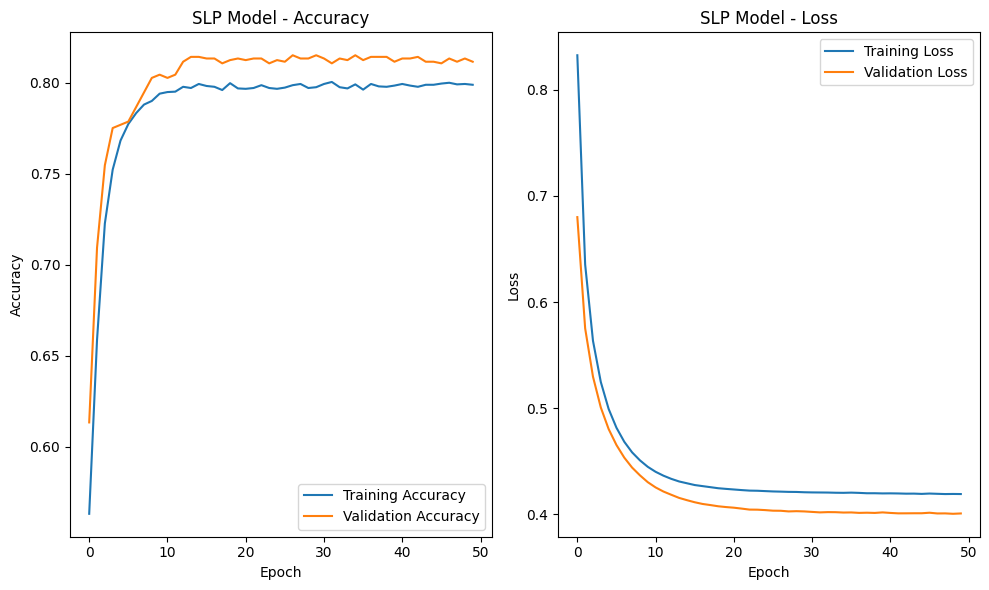

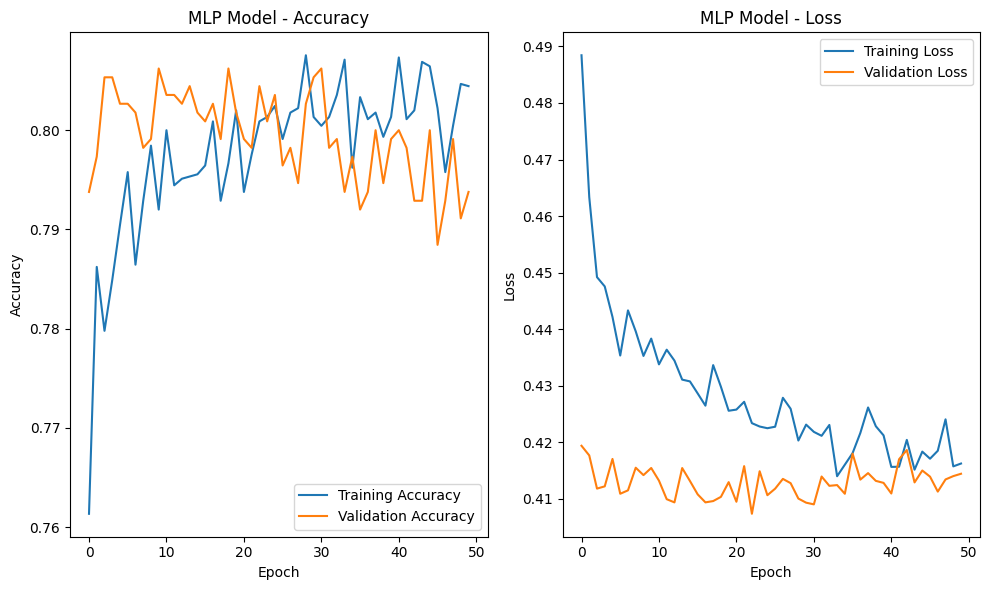

In [32]:
def plot_history(history, title):
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{title} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{title} - Loss')

    plt.tight_layout()
    plt.show()

plot_history(history_slp, 'SLP Model')
plot_history(history_mlp, 'MLP Model')

slp balance

mlp overfitt

ini mlp yang diatas udh ga overfitt, karena udh di dropout

In [33]:
# solve overfitt pake drop 0.2